# Notebook 04: Feature Engineering (XGBoost y MLP)

## Objetivo

**Queremos entender qué tan bien elegido está el set de 14 features.**

Nos basamos en dos señales, una por modelo: **SHAP** para XGBoost (mide el impacto real de cada feature en el output del modelo, no solo cuántas veces se usó en un split) y **permutation importance** para MLP.

Con esa señal armamos dos análisis, repetidos para XGBoost y para MLP:

1. **Adición acumulativa**: ordenamos las features por importancia y entrenamos el modelo agregando una feature a la vez (primero solo la más importante, después las dos más importantes, etc.), midiendo AUC en train y val en cada paso. Esto muestra si más features siempre ayuda, o si en algún punto empezamos a overfitear.
2. **Leave-one-out**: partiendo del modelo con las 14 features, sacamos una feature a la vez y medimos cuánto cae (o sube) el AUC de val respecto al modelo completo. Esto muestra el aporte marginal de cada feature *dentro* del set completo. Puede diferir del ranking de importancia porque acá entra en juego la redundancia entre features correlacionadas.

Al final, también probamos si agregar features de interacción (multiplicación entre pares de features) suma señal adicional.

In [25]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from src import models, utils

utils.set_plot_style()

PROCESSED_DIR = "../data/processed"

# Mismo set de 14 features que en el notebook 03 (técnicas + macro + riesgo geopolítico)
FEATURE_COLS = [
    "RSI_14", "MACD", "BB_position", "return_1d", "return_5d", "volume_change",  # técnicas
    "vix", "t10y2y", "fedfunds", "cpi", "unrate",  # macro
    "GPRD", "GPRD_ACT", "GPRD_THREAT",  # riesgo geopolítico
]

df = pd.read_csv(f"{PROCESSED_DIR}/sp500_features.csv", index_col=0, parse_dates=True)
df = df.dropna(subset=FEATURE_COLS)
print(f"Dataset: {df.shape} | {df.index[0].date()} → {df.index[-1].date()}")

Dataset: (4613, 20) | 2008-02-13 → 2026-06-16


## Split temporal y escalado

Mismo criterio que en el resto del proyecto: split temporal sin shuffle (train hasta 2024, val 2025), y `StandardScaler` fiteado solo sobre train. XGBoost no lo necesita para funcionar, pero lo dejamos para reusar `models.evaluate_model()` y compararlo con los otros notebooks sin ambigüedad.

In [26]:
X_train, X_val, X_test, y_train, y_val, y_test = models.temporal_split(
    df, features=FEATURE_COLS, target="target"
)

X_train_s, X_val_s, X_test_s, scaler = models.scale_features(X_train, X_val, X_test)

[models] Split temporal:
  train: 4,249 muestras (2008-02-13 → 2024-12-31)
  val:   250 muestras (2025-01-02 → 2025-12-31)
  test:  114 muestras (2026-01-02 → 2026-06-16)


## Baseline: XGBoost con las 14 features

Punto de referencia contra el que vamos a comparar todo lo que sigue.

In [27]:
xgb_full = models.train_xgboost(X_train_s, y_train, X_val_s, y_val)

metricas_train = models.evaluate_model(xgb_full, X_train_s, y_train, "train")
metricas_val   = models.evaluate_model(xgb_full, X_val_s, y_val, "val")

baseline_val_auc = metricas_val["roc_auc"]
print(f"\nAUC val de referencia (14 features): {baseline_val_auc}")

[models] XGBoost entrenado. Mejor ronda: 20

── TRAIN ──
  accuracy    : 0.6324
  f1          : 0.6321
  roc_auc     : 0.6877
  precision   : 0.6319
  recall      : 0.6324

── VAL ──
  accuracy    : 0.46
  f1          : 0.3698
  roc_auc     : 0.5767
  precision   : 0.5834
  recall      : 0.46

AUC val de referencia (14 features): 0.5767


## Ranking de importancia SHAP

Calculamos SHAP sobre el modelo baseline  y nos quedamos con el promedio de `|shap|` por feature: un solo número por feature que resume su impacto global en las predicciones. Ese ranking es el que usamos para ordenar la adición acumulativa de abajo.

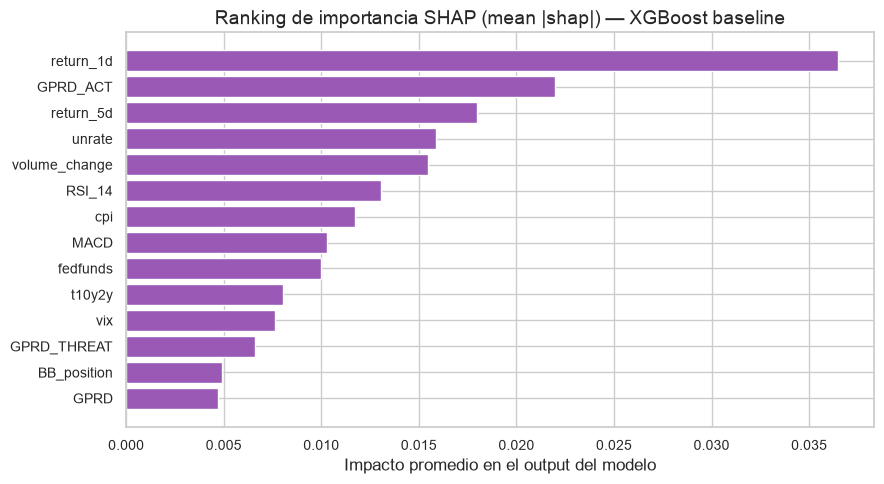

return_1d        0.036498
GPRD_ACT         0.021984
return_5d        0.017969
unrate           0.015895
volume_change    0.015483
RSI_14           0.013053
cpi              0.011722
MACD             0.010267
fedfunds         0.009968
t10y2y           0.008037
vix              0.007618
GPRD_THREAT      0.006619
BB_position      0.004933
GPRD             0.004707
dtype: float32


In [28]:
explainer  = shap.TreeExplainer(xgb_full)
shap_train = explainer.shap_values(pd.DataFrame(X_train_s, columns=FEATURE_COLS))

shap_rank = pd.Series(np.abs(shap_train).mean(axis=0), index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.barh(shap_rank.index[::-1], shap_rank.values[::-1], color="#9b59b6")
plt.title("Ranking de importancia SHAP (mean |shap|) — XGBoost baseline")
plt.xlabel("Impacto promedio en el output del modelo")
plt.tight_layout()
plt.show()

print(shap_rank)

## Adición acumulativa de features (ordenadas por SHAP)

Entrenamos XGBoost 14 veces: primero solo con la feature más importante según SHAP, después con las 2 más importantes, y así hasta llegar a las 14. En cada paso medimos AUC de train y de val.

**Qué buscamos**: si el AUC de val deja de mejorar (o empieza a caer) antes de llegar a las 14 features mientras el de train sigue subiendo, es una señal de que las features menos importantes están aportando ruido/overfitting en vez de señal.

In [29]:
cols_por_importancia = shap_rank.index.tolist()

resultados_cum = []
for k in range(1, len(cols_por_importancia) + 1):
    cols_k = cols_por_importancia[:k]
    idx = [FEATURE_COLS.index(c) for c in cols_k]

    Xtr_k = X_train_s[:, idx]
    Xvl_k = X_val_s[:, idx]

    xgb_k = models.train_xgboost(Xtr_k, y_train, Xvl_k, y_val)

    train_auc_k = models.evaluate_model(xgb_k, Xtr_k, y_train, f"train (k={k})")["roc_auc"]
    val_auc_k   = models.evaluate_model(xgb_k, Xvl_k, y_val, f"val (k={k})")["roc_auc"]

    resultados_cum.append({
        "k": k,
        "feature_agregada": cols_k[-1],
        "train_auc": train_auc_k,
        "val_auc": val_auc_k,
    })

cum_df = pd.DataFrame(resultados_cum)
cum_df

[models] XGBoost entrenado. Mejor ronda: 3

── TRAIN (K=1) ──
  accuracy    : 0.5481
  f1          : 0.5426
  roc_auc     : 0.5584
  precision   : 0.5431
  recall      : 0.5481

── VAL (K=1) ──
  accuracy    : 0.524
  f1          : 0.5249
  roc_auc     : 0.5388
  precision   : 0.5259
  recall      : 0.524
[models] XGBoost entrenado. Mejor ronda: 3

── TRAIN (K=2) ──
  accuracy    : 0.5481
  f1          : 0.5426
  roc_auc     : 0.5584
  precision   : 0.5431
  recall      : 0.5481

── VAL (K=2) ──
  accuracy    : 0.524
  f1          : 0.5249
  roc_auc     : 0.5388
  precision   : 0.5259
  recall      : 0.524
[models] XGBoost entrenado. Mejor ronda: 3

── TRAIN (K=3) ──
  accuracy    : 0.5557
  f1          : 0.5565
  roc_auc     : 0.5841
  precision   : 0.56
  recall      : 0.5557

── VAL (K=3) ──
  accuracy    : 0.516
  f1          : 0.5157
  roc_auc     : 0.536
  precision   : 0.5439
  recall      : 0.516
[models] XGBoost entrenado. Mejor ronda: 23

── TRAIN (K=4) ──
  accuracy    : 0.6

,k,feature_agregada,train_auc,val_auc
0,1,return_1d,0.5584,0.5388
1,2,GPRD_ACT,0.5584,0.5388
2,3,return_5d,0.5841,0.5360
3,4,unrate,0.6473,0.5318
4,5,volume_change,0.6775,0.5759
5,6,RSI_14,0.6188,0.5920
6,7,cpi,0.6186,0.5721
7,8,MACD,0.7059,0.5622
8,9,fedfunds,0.7145,0.5514
9,10,t10y2y,0.6992,0.5672


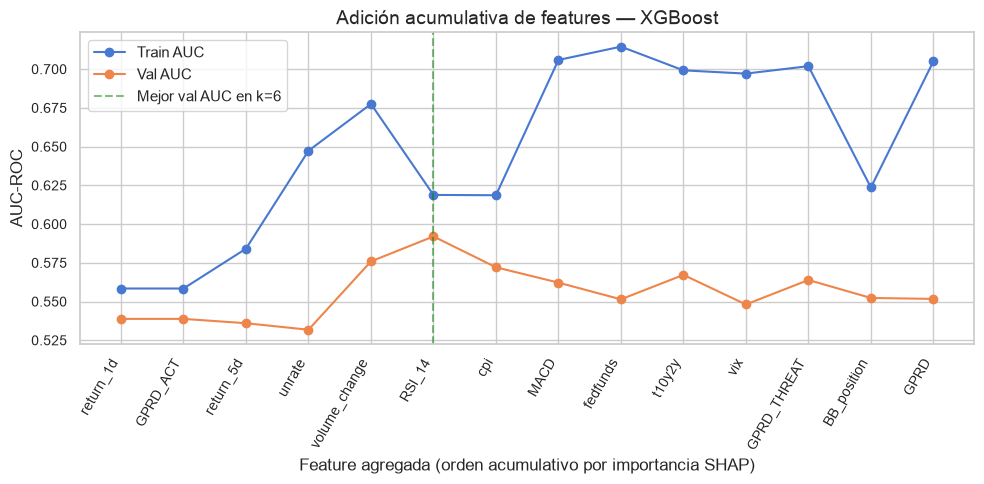

Mejor val AUC: 0.592 con k=6 features (vs. 0.5767 con las 14 completas)


In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cum_df["k"], cum_df["train_auc"], marker="o", label="Train AUC")
ax.plot(cum_df["k"], cum_df["val_auc"], marker="o", label="Val AUC")

mejor_k = cum_df.loc[cum_df["val_auc"].idxmax()]
ax.axvline(mejor_k["k"], color="green", linestyle="--", alpha=0.5,
           label=f"Mejor val AUC en k={int(mejor_k['k'])}")

ax.set_xticks(cum_df["k"])
ax.set_xticklabels(cum_df["feature_agregada"], rotation=60, ha="right")
ax.set_xlabel("Feature agregada (orden acumulativo por importancia SHAP)")
ax.set_ylabel("AUC-ROC")
ax.set_title("Adición acumulativa de features — XGBoost")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mejor val AUC: {mejor_k['val_auc']} con k={int(mejor_k['k'])} features "
      f"(vs. {baseline_val_auc} con las 14 completas)")

## Leave-one-out sobre el modelo completo

Partiendo de las 14 features, entrenamos 14 modelos más, cada uno sacando una feature distinta, y comparamos el AUC de val contra el baseline. Un delta muy negativo significa que esa feature es difícil de reemplazar con las demás; un delta cercano a 0 significa que su información ya está cubierta por el resto (redundancia), no necesariamente que la feature "no sirva" en general.

In [31]:
resultados_loo = []
for feat in FEATURE_COLS:
    cols_sin_feat = [c for c in FEATURE_COLS if c != feat]
    idx = [FEATURE_COLS.index(c) for c in cols_sin_feat]

    Xtr_wo = X_train_s[:, idx]
    Xvl_wo = X_val_s[:, idx]

    xgb_wo = models.train_xgboost(Xtr_wo, y_train, Xvl_wo, y_val)
    val_auc_wo = models.evaluate_model(xgb_wo, Xvl_wo, y_val, f"val sin {feat}")["roc_auc"]

    resultados_loo.append({
        "feature_removida": feat,
        "val_auc_sin_feature": val_auc_wo,
        "delta_vs_completo": round(val_auc_wo - baseline_val_auc, 4),
    })

loo_df = pd.DataFrame(resultados_loo).sort_values("delta_vs_completo")
loo_df

[models] XGBoost entrenado. Mejor ronda: 57

── VAL SIN RSI_14 ──
  accuracy    : 0.48
  f1          : 0.4548
  roc_auc     : 0.5333
  precision   : 0.5362
  recall      : 0.48
[models] XGBoost entrenado. Mejor ronda: 2

── VAL SIN MACD ──
  accuracy    : 0.532
  f1          : 0.5268
  roc_auc     : 0.5721
  precision   : 0.5723
  recall      : 0.532
[models] XGBoost entrenado. Mejor ronda: 20

── VAL SIN BB_POSITION ──
  accuracy    : 0.46
  f1          : 0.4154
  roc_auc     : 0.528
  precision   : 0.524
  recall      : 0.46
[models] XGBoost entrenado. Mejor ronda: 12

── VAL SIN RETURN_1D ──
  accuracy    : 0.456
  f1          : 0.3755
  roc_auc     : 0.5013
  precision   : 0.5545
  recall      : 0.456
[models] XGBoost entrenado. Mejor ronda: 44

── VAL SIN RETURN_5D ──
  accuracy    : 0.512
  f1          : 0.4985
  roc_auc     : 0.54
  precision   : 0.5636
  recall      : 0.512
[models] XGBoost entrenado. Mejor ronda: 0

── VAL SIN VOLUME_CHANGE ──
  accuracy    : 0.5
  f1         

,feature_removida,val_auc_sin_feature,delta_vs_completo
3,return_1d,0.5013,-0.0754
5,volume_change,0.5209,-0.0558
12,GPRD_ACT,0.5273,-0.0494
2,BB_position,0.5280,-0.0487
0,RSI_14,0.5333,-0.0434
4,return_5d,0.5400,-0.0367
6,vix,0.5421,-0.0346
9,cpi,0.5451,-0.0316
8,fedfunds,0.5482,-0.0285
7,t10y2y,0.5601,-0.0166


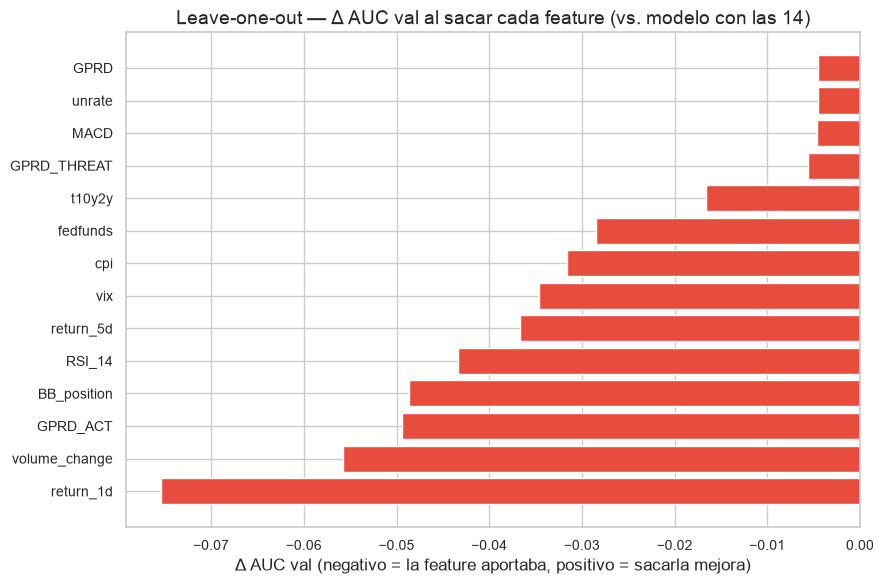

In [32]:
plt.figure(figsize=(9, 6))
colores = ["#e74c3c" if d < 0 else "#2ecc71" for d in loo_df["delta_vs_completo"]]
plt.barh(loo_df["feature_removida"], loo_df["delta_vs_completo"], color=colores)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Leave-one-out — Δ AUC val al sacar cada feature (vs. modelo con las 14)")
plt.xlabel("Δ AUC val (negativo = la feature aportaba, positivo = sacarla mejora)")
plt.tight_layout()
plt.show()

## Mismo análisis para MLP

`shap.TreeExplainer()` explota la estructura de árboles de XGBoost para calcular
los valores SHAP de forma exacta. No existe un equivalente directo para una red
densa como el MLP. En vez de sumar esa complejidad, usamos **permutation importance**
(`sklearn.inspection.permutation_importance`): mide cuánto empeora el AUC de val
cuando se desordena (shuffle) una columna a la vez, manteniendo el modelo fijo.

Repetimos la misma estructura de análisis que hicimos para XGBoost, ahora
con `models.train_mlp()`.

In [33]:
mlp_full = models.train_mlp(X_train_s, y_train, X_val_s, y_val)

metricas_train_mlp = models.evaluate_model(mlp_full, X_train_s, y_train, "train")
metricas_val_mlp   = models.evaluate_model(mlp_full, X_val_s, y_val, "val")

baseline_val_auc_mlp = metricas_val_mlp["roc_auc"]
print(f"\nAUC val de referencia MLP (14 features): {baseline_val_auc_mlp}")


── TRAIN ──
  accuracy    : 0.5888
  f1          : 0.5518
  roc_auc     : 0.6167
  precision   : 0.5946
  recall      : 0.5888

── VAL ──
  accuracy    : 0.492
  f1          : 0.4946
  roc_auc     : 0.5167
  precision   : 0.5105
  recall      : 0.492

AUC val de referencia MLP (14 features): 0.5167


### Permutation importance (reemplazo de SHAP para MLP)

`n_repeats=20` para que el promedio no dependa de una sola corrida de shuffle
(el MLP es bastante más sensible a la inicialización que XGBoost, así que la
importancia individual puede variar más de una corrida a otra).

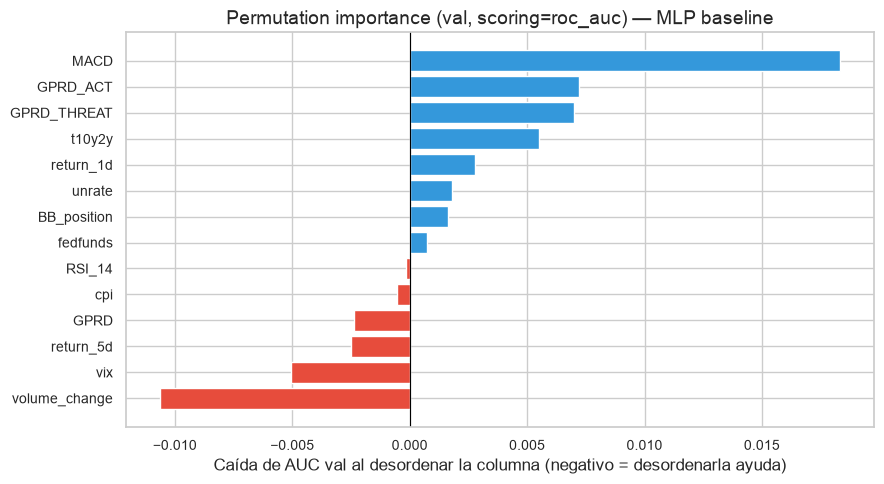

MACD             0.018325
GPRD_ACT         0.007215
GPRD_THREAT      0.007002
t10y2y           0.005511
return_1d        0.002795
unrate           0.001790
BB_position      0.001612
fedfunds         0.000732
RSI_14          -0.000154
cpi             -0.000532
GPRD            -0.002371
return_5d       -0.002486
vix             -0.005051
volume_change   -0.010627
dtype: float64


In [34]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    mlp_full, X_val_s, y_val, scoring="roc_auc", n_repeats=20, random_state=42
)
perm_rank = pd.Series(perm.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
colores_perm = ["#e74c3c" if v < 0 else "#3498db" for v in perm_rank.values[::-1]]
plt.barh(perm_rank.index[::-1], perm_rank.values[::-1], color=colores_perm)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Permutation importance (val, scoring=roc_auc) — MLP baseline")
plt.xlabel("Caída de AUC val al desordenar la columna (negativo = desordenarla ayuda)")
plt.tight_layout()
plt.show()

print(perm_rank)

### Adición acumulativa (MLP, ordenado por permutation importance)

Misma lógica que con XGBoost: vamos agregando features de a una, en orden de
importancia, y medimos AUC de train y val en cada paso.

In [35]:
cols_por_importancia_mlp = perm_rank.index.tolist()

resultados_cum_mlp = []
for k in range(1, len(cols_por_importancia_mlp) + 1):
    cols_k = cols_por_importancia_mlp[:k]
    idx = [FEATURE_COLS.index(c) for c in cols_k]

    Xtr_k = X_train_s[:, idx]
    Xvl_k = X_val_s[:, idx]

    mlp_k = models.train_mlp(Xtr_k, y_train, Xvl_k, y_val)

    train_auc_k = models.evaluate_model(mlp_k, Xtr_k, y_train, f"train (k={k})")["roc_auc"]
    val_auc_k   = models.evaluate_model(mlp_k, Xvl_k, y_val, f"val (k={k})")["roc_auc"]

    resultados_cum_mlp.append({
        "k": k,
        "feature_agregada": cols_k[-1],
        "train_auc": train_auc_k,
        "val_auc": val_auc_k,
    })

cum_df_mlp = pd.DataFrame(resultados_cum_mlp)
cum_df_mlp


── TRAIN (K=1) ──
  accuracy    : 0.5427
  f1          : 0.4038
  roc_auc     : 0.516
  precision   : 0.5218
  recall      : 0.5427

── VAL (K=1) ──
  accuracy    : 0.532
  f1          : 0.5158
  roc_auc     : 0.5285
  precision   : 0.5135
  recall      : 0.532

── TRAIN (K=2) ──
  accuracy    : 0.543
  f1          : 0.3821
  roc_auc     : 0.5087
  precision   : 0.2948
  recall      : 0.543

── VAL (K=2) ──
  accuracy    : 0.58
  f1          : 0.4258
  roc_auc     : 0.5048
  precision   : 0.3364
  recall      : 0.58

── TRAIN (K=3) ──
  accuracy    : 0.5505
  f1          : 0.4326
  roc_auc     : 0.5389
  precision   : 0.56
  recall      : 0.5505

── VAL (K=3) ──
  accuracy    : 0.556
  f1          : 0.5436
  roc_auc     : 0.5352
  precision   : 0.5423
  recall      : 0.556

── TRAIN (K=4) ──
  accuracy    : 0.5561
  f1          : 0.4328
  roc_auc     : 0.5726
  precision   : 0.6
  recall      : 0.5561

── VAL (K=4) ──
  accuracy    : 0.528
  f1          : 0.4672
  roc_auc     : 0.5132

,k,feature_agregada,train_auc,val_auc
0,1,MACD,0.5160,0.5285
1,2,GPRD_ACT,0.5087,0.5048
2,3,GPRD_THREAT,0.5389,0.5352
3,4,t10y2y,0.5726,0.5132
4,5,return_1d,0.5437,0.4588
5,6,unrate,0.5920,0.5265
6,7,BB_position,0.5603,0.5032
7,8,fedfunds,0.6128,0.5404
8,9,RSI_14,0.5234,0.4847
9,10,cpi,0.5731,0.4998


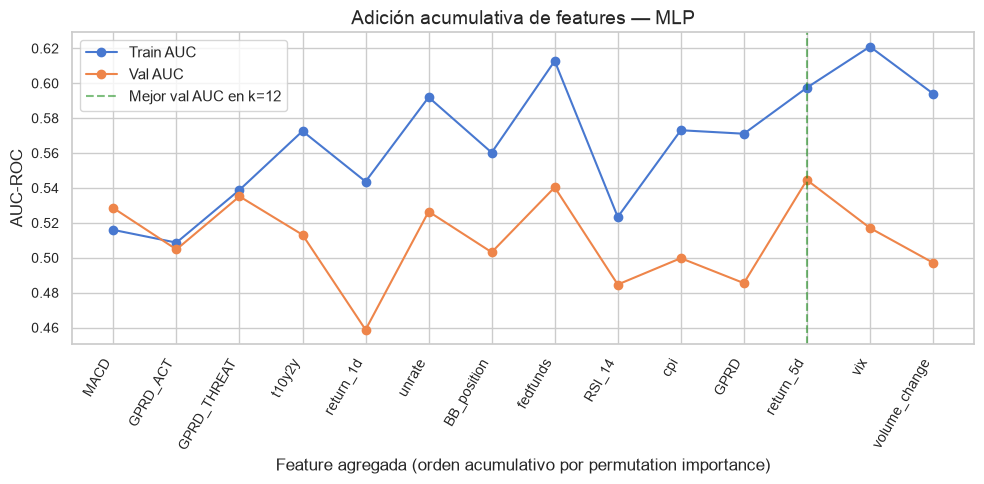

Mejor val AUC: 0.5446 con k=12 features (vs. 0.5167 con las 14 completas)


In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cum_df_mlp["k"], cum_df_mlp["train_auc"], marker="o", label="Train AUC")
ax.plot(cum_df_mlp["k"], cum_df_mlp["val_auc"], marker="o", label="Val AUC")

mejor_k_mlp = cum_df_mlp.loc[cum_df_mlp["val_auc"].idxmax()]
ax.axvline(mejor_k_mlp["k"], color="green", linestyle="--", alpha=0.5,
           label=f"Mejor val AUC en k={int(mejor_k_mlp['k'])}")

ax.set_xticks(cum_df_mlp["k"])
ax.set_xticklabels(cum_df_mlp["feature_agregada"], rotation=60, ha="right")
ax.set_xlabel("Feature agregada (orden acumulativo por permutation importance)")
ax.set_ylabel("AUC-ROC")
ax.set_title("Adición acumulativa de features — MLP")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mejor val AUC: {mejor_k_mlp['val_auc']} con k={int(mejor_k_mlp['k'])} features "
      f"(vs. {baseline_val_auc_mlp} con las 14 completas)")

### Leave-one-out (MLP)

In [37]:
resultados_loo_mlp = []
for feat in FEATURE_COLS:
    cols_sin_feat = [c for c in FEATURE_COLS if c != feat]
    idx = [FEATURE_COLS.index(c) for c in cols_sin_feat]

    Xtr_wo = X_train_s[:, idx]
    Xvl_wo = X_val_s[:, idx]

    mlp_wo = models.train_mlp(Xtr_wo, y_train, Xvl_wo, y_val)
    val_auc_wo = models.evaluate_model(mlp_wo, Xvl_wo, y_val, f"val sin {feat}")["roc_auc"]

    resultados_loo_mlp.append({
        "feature_removida": feat,
        "val_auc_sin_feature": val_auc_wo,
        "delta_vs_completo": round(val_auc_wo - baseline_val_auc_mlp, 4),
    })

loo_df_mlp = pd.DataFrame(resultados_loo_mlp).sort_values("delta_vs_completo")
loo_df_mlp


── VAL SIN RSI_14 ──
  accuracy    : 0.516
  f1          : 0.5126
  roc_auc     : 0.5021
  precision   : 0.5507
  recall      : 0.516

── VAL SIN MACD ──
  accuracy    : 0.504
  f1          : 0.4939
  roc_auc     : 0.4943
  precision   : 0.49
  recall      : 0.504

── VAL SIN BB_POSITION ──
  accuracy    : 0.504
  f1          : 0.5026
  roc_auc     : 0.509
  precision   : 0.5335
  recall      : 0.504

── VAL SIN RETURN_1D ──
  accuracy    : 0.516
  f1          : 0.5169
  roc_auc     : 0.5023
  precision   : 0.5408
  recall      : 0.516

── VAL SIN RETURN_5D ──
  accuracy    : 0.5
  f1          : 0.5018
  roc_auc     : 0.4934
  precision   : 0.5214
  recall      : 0.5

── VAL SIN VOLUME_CHANGE ──
  accuracy    : 0.496
  f1          : 0.4863
  roc_auc     : 0.5191
  precision   : 0.5381
  recall      : 0.496

── VAL SIN VIX ──
  accuracy    : 0.496
  f1          : 0.4938
  roc_auc     : 0.5086
  precision   : 0.5265
  recall      : 0.496

── VAL SIN T10Y2Y ──
  accuracy    : 0.576
  f1 

,feature_removida,val_auc_sin_feature,delta_vs_completo
4,return_5d,0.4934,-0.0233
1,MACD,0.4943,-0.0224
12,GPRD_ACT,0.4966,-0.0201
7,t10y2y,0.4981,-0.0186
0,RSI_14,0.5021,-0.0146
13,GPRD_THREAT,0.5022,-0.0145
3,return_1d,0.5023,-0.0144
11,GPRD,0.5038,-0.0129
8,fedfunds,0.5050,-0.0117
6,vix,0.5086,-0.0081


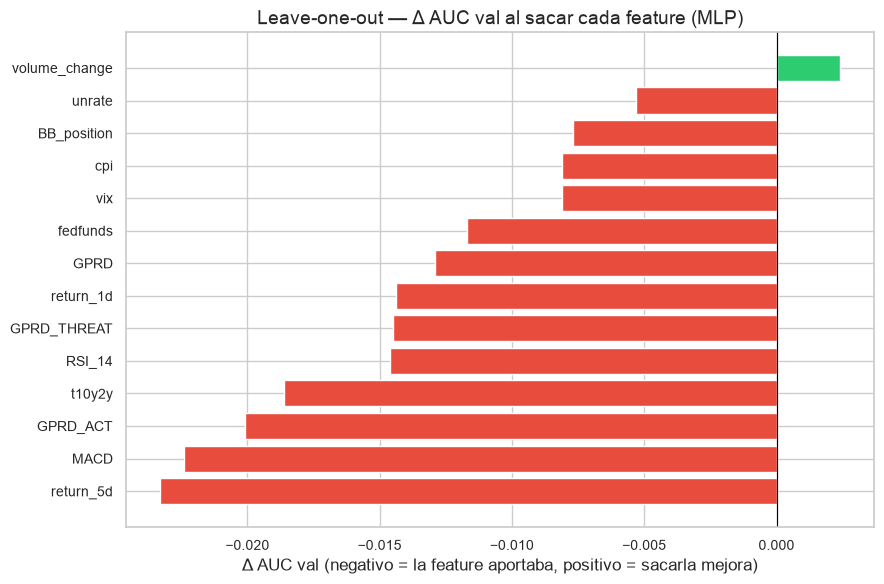

In [38]:
plt.figure(figsize=(9, 6))
colores_loo_mlp = ["#e74c3c" if d < 0 else "#2ecc71" for d in loo_df_mlp["delta_vs_completo"]]
plt.barh(loo_df_mlp["feature_removida"], loo_df_mlp["delta_vs_completo"], color=colores_loo_mlp)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Leave-one-out — Δ AUC val al sacar cada feature (MLP)")
plt.xlabel("Δ AUC val (negativo = la feature aportaba, positivo = sacarla mejora)")
plt.tight_layout()
plt.show()

## Ahora sí: probamos las interacciones entre features

En la conclusión de arriba habíamos dejado dos candidatas sin implementar:
`return_1d × vix` y `RSI_14 × volume_change`. Sumamos una tercera motivada por
lo que vimos en ambos rankings de importancia: `GPRD_ACT` aparece consistentemente
arriba en los dos modelos, así que probamos si combinarla con `return_1d`
(¿un shock geopolítico realizado amplifica el movimiento del día?) suma algo.

Construimos las 3 columnas nuevas por multiplicación directa (sin ninguna
transformación extra) y comparamos **train y val AUC de XGBoost y de MLP**,
cada uno con sus 14 features originales + las 3 interacciones (17 en total),
contra los baselines de cada modelo que ya calculamos arriba.

In [39]:
df["inter_return1d_vix"]      = df["return_1d"] * df["vix"]
df["inter_rsi_volchange"]     = df["RSI_14"] * df["volume_change"]
df["inter_gprdact_return1d"]  = df["GPRD_ACT"] * df["return_1d"]

INTER_COLS = ["inter_return1d_vix", "inter_rsi_volchange", "inter_gprdact_return1d"]
FEATURE_COLS_INTER = FEATURE_COLS + INTER_COLS

df_inter = df.dropna(subset=FEATURE_COLS_INTER)
print(f"Dataset con interacciones: {df_inter.shape}")

X_train_i, X_val_i, X_test_i, y_train_i, y_val_i, y_test_i = models.temporal_split(
    df_inter, features=FEATURE_COLS_INTER, target="target"
)
X_train_is, X_val_is, X_test_is, scaler_i = models.scale_features(X_train_i, X_val_i, X_test_i)

Dataset con interacciones: (4613, 23)
[models] Split temporal:
  train: 4,249 muestras (2008-02-13 → 2024-12-31)
  val:   250 muestras (2025-01-02 → 2025-12-31)
  test:  114 muestras (2026-01-02 → 2026-06-16)


In [40]:
print("── XGBoost + interacciones (17 features) ──")
xgb_inter = models.train_xgboost(X_train_is, y_train_i, X_val_is, y_val_i)
xgb_inter_train = models.evaluate_model(xgb_inter, X_train_is, y_train_i, "train")
xgb_inter_val   = models.evaluate_model(xgb_inter, X_val_is, y_val_i, "val")

print("\n── MLP + interacciones (17 features) ──")
mlp_inter = models.train_mlp(X_train_is, y_train_i, X_val_is, y_val_i)
mlp_inter_train = models.evaluate_model(mlp_inter, X_train_is, y_train_i, "train")
mlp_inter_val   = models.evaluate_model(mlp_inter, X_val_is, y_val_i, "val")

tabla_interacciones = pd.DataFrame([
    {"Modelo": "XGBoost", "Features": "14 (baseline)", "train_auc": metricas_train["roc_auc"], "val_auc": metricas_val["roc_auc"]},
    {"Modelo": "XGBoost", "Features": "17 (+ interacciones)", "train_auc": xgb_inter_train["roc_auc"], "val_auc": xgb_inter_val["roc_auc"]},
    {"Modelo": "MLP",     "Features": "14 (baseline)", "train_auc": metricas_train_mlp["roc_auc"], "val_auc": metricas_val_mlp["roc_auc"]},
    {"Modelo": "MLP",     "Features": "17 (+ interacciones)", "train_auc": mlp_inter_train["roc_auc"], "val_auc": mlp_inter_val["roc_auc"]},
])
tabla_interacciones

── XGBoost + interacciones (17 features) ──
[models] XGBoost entrenado. Mejor ronda: 4

── TRAIN ──
  accuracy    : 0.5891
  f1          : 0.5821
  roc_auc     : 0.6242
  precision   : 0.5853
  recall      : 0.5891

── VAL ──
  accuracy    : 0.52
  f1          : 0.5216
  roc_auc     : 0.5508
  precision   : 0.5427
  recall      : 0.52

── MLP + interacciones (17 features) ──

── TRAIN ──
  accuracy    : 0.67
  f1          : 0.6661
  roc_auc     : 0.7298
  precision   : 0.6695
  recall      : 0.67

── VAL ──
  accuracy    : 0.464
  f1          : 0.4586
  roc_auc     : 0.4676
  precision   : 0.4955
  recall      : 0.464


,Modelo,Features,train_auc,val_auc
0,XGBoost,14 (baseline),0.6877,0.5767
1,XGBoost,17 (+ interacciones),0.6242,0.5508
2,MLP,14 (baseline),0.6167,0.5167
3,MLP,17 (+ interacciones),0.7298,0.4676


## Conclusión final sobre las interacciones

Con los datos reales del proyecto, agregar las 3 interacciones **no ayudó a
ninguno de los dos modelos**:

| Modelo | Features | Train AUC | Val AUC |
|---|---|---|---|
| XGBoost | 14 (baseline) | 0.688 | 0.577 |
| XGBoost | 17 (+ interacciones) | 0.624 | 0.551 |
| MLP | 14 (baseline) | 0.617 | 0.517 |
| MLP | 17 (+ interacciones) | 0.730 | 0.468 |

En **XGBoost** el early stopping cortó mucho antes con las interacciones
adentro (ronda 4 vs. ronda 20 del baseline): el val AUC dejó de mejorar más
rápido, así que el modelo ni siquiera llegó a ajustar tan bien como el
baseline en train. En **MLP** pasa lo contrario y es más claro todavía: train
AUC sube fuerte (0.62 → 0.73) pero val cae (0.52 → 0.47), un caso de manual
de overfitting: la red aprovecha la columna extra para memorizar train sin
que eso generalice.

Una hipótesis de por qué: multiplicar dos variables ruidosas (cada una con
poca señal individual, según los rankings de arriba) no crea una señal nueva,
amplifica el ruido de ambas. Además, el producto tiene una distribución
con cola mucho más pesada que cualquiera de sus dos factores por separado,
lo que complica tanto a los splits de XGBoost como al gradiente
del MLP.

El camino que sí mostró mejoras concretas en este notebook fue el de
**reducir** el set de 14 a un subconjunto más chico guiado por SHAP
(XGBoost) o permutation importance (MLP).

**Decisión de selección de features**: cada arquitectura queda con su propio
subconjunto óptimo, encontrado en los experimentos de arriba.

Para **XGBoost** se utilizarán 6 features: `return_1d`, `GPRD_ACT`, `return_5d`, `unrate`, `volume_change` y `RSI_14`.

Para **MLP** se utilizarán 12 features: `RSI_14`, `MACD`, `BB_position`, `return_1d`, `return_5d`, `t10y2y`, `fedfunds`, `cpi`, `unrate`, `GPRD`, `GPRD_ACT` y `GPRD_THREAT`.